# Alanine dipeptide

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/craabreu/openmm-opes/blob/main/docs/examples/alanine_dipeptide.ipynb)

OPES applied to alanine dipeptide in vacuum, biasing the backbone dihedral
angles $\phi$ and $\psi$. The run recovers the Ramachandran free energy
surface, and we follow the C7eq–C7ax free energy difference and the barrier
between them as the bias converges.

On Google Colab, the next cell installs the package and fetches the structure
file. Elsewhere it does nothing.

In [1]:
import os
import sys

if "google.colab" in sys.modules:
    !pip install -q openmm-opes matplotlib
    if not os.path.exists("alanine_dipeptide.pdb"):
        !wget -q https://raw.githubusercontent.com/craabreu/openmm-opes/main/docs/examples/alanine_dipeptide.pdb

## System

Amber14 in vacuum with no cutoff, hydrogen bonds constrained, and a 2 fs
Langevin integrator at 300 K.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import openmm as mm
from openmm import app, unit
from scipy.cluster.hierarchy import DisjointSet

from openmm_opes import OPES

temperature = 300 * unit.kelvin
pdb = app.PDBFile("alanine_dipeptide.pdb")
forcefield = app.ForceField("amber14-all.xml")
system = forcefield.createSystem(
    pdb.topology, nonbondedMethod=app.NoCutoff, constraints=app.HBonds
)

## Collective variables

Both dihedrals are periodic on $[-\pi, \pi]$. The bias lives on a
$101 \times 101$ grid.

In [3]:
atoms = {(atom.residue.name, atom.name): atom.index for atom in pdb.topology.atoms()}


def dihedral(*names):
    force = mm.CustomTorsionForce("theta")
    force.addTorsion(*(atoms[name] for name in names))
    return app.BiasVariable(force, -np.pi, np.pi, 0.15, True, 101)


phi = dihedral(("ACE", "C"), ("ALA", "N"), ("ALA", "CA"), ("ALA", "C"))
psi = dihedral(("ALA", "N"), ("ALA", "CA"), ("ALA", "C"), ("NME", "N"))

## Sampler

The `biasWidth` of 0.15 rad passed above is the initial bandwidth
$\sigma^{(0)}$, held fixed by `varianceFrequency=None`. It is roughly the
width of the narrower basin. A `warmupSteps` measurement would not do here:
an unbiased trajectory hops between C7eq and C5 along $\psi$ within
picoseconds, so its variance spans both basins and the kernels come out
several times too wide.

A kernel is deposited every 500 steps (1 ps), with a barrier of 50 kJ/mol and
a bias factor of 10.

In [4]:
sampler = OPES(
    system,
    [phi, psi],
    temperature,
    barrier=50 * unit.kilojoules_per_mole,
    frequency=500,
    varianceFrequency=None,
    biasFactor=10,
)

integrator = mm.LangevinMiddleIntegrator(
    temperature, 1 / unit.picosecond, 2 * unit.femtoseconds
)
platform = mm.Platform.getPlatformByName("Reference")
simulation = app.Simulation(pdb.topology, system, integrator, platform)
simulation.context.setPositions(pdb.positions)
simulation.context.setVelocitiesToTemperature(temperature)

The Reference platform is the fastest choice for a 22-atom system in vacuum:
the GPU platforms spend more time launching kernels than computing forces.

## Convergence metrics

Two quantities read off the free energy surface:

- **$\Delta F$**, the free energy of the region $\phi \in [0, 2.3]$
  (C7ax) relative to the rest, in units of $k_B T$.
- **Barrier**, the highest point along the lowest path from the C7eq minimum
  to the C7ax minimum, found by flooding the periodic grid from the bottom up
  until the two minima join.

In [5]:
kT = (unit.MOLAR_GAS_CONSTANT_R * temperature).value_in_unit(unit.kilojoules_per_mole)
grid = np.linspace(-np.pi, np.pi, 101)
PHI, PSI = np.meshgrid(grid, grid)
c7ax = (PHI > 0) & (PHI < 2.3)


def deltaF(fes):
    weights = np.exp(-(fes - fes.min()) / kT)
    return -np.log(weights[c7ax].sum() / weights[~c7ax].sum())


def barrier(fes):
    f = fes[:-1, :-1]
    rows, cols = f.shape
    start = np.argmin(np.where(PHI[:-1, :-1] < 0, f, np.inf))
    end = np.argmin(np.where(c7ax[:-1, :-1], f, np.inf))
    nodes = DisjointSet(range(f.size))
    flooded = np.zeros(f.size, dtype=bool)
    for k in np.argsort(f, axis=None):
        flooded[k] = True
        i, j = divmod(k, cols)
        for di, dj in ((1, 0), (-1, 0), (0, 1), (0, -1)):
            neighbor = (i + di) % rows * cols + (j + dj) % cols
            if flooded[neighbor]:
                nodes.merge(k, neighbor)
        if flooded[start] and flooded[end] and nodes.connected(start, end):
            return f.flat[k] - f.flat[start]

## Run

Ten nanoseconds, recording the dihedrals every picosecond and the two
metrics every 0.1 ns.

In [6]:
times, metrics, trajectory = [], [], []
for block in range(100):
    for _ in range(100):
        sampler.step(simulation, 500)
        trajectory.append(sampler.getCollectiveVariables(simulation))
    fes = sampler.getFreeEnergy().value_in_unit(unit.kilojoules_per_mole)
    times.append((block + 1) / 10)
    metrics.append((deltaF(fes), barrier(fes)))
trajectory = np.array(trajectory)
metrics = np.array(metrics)
print(f"{sampler.getNumKernels()} kernels")
print(f"Delta F = {metrics[-1, 0]:.2f} kT, barrier = {metrics[-1, 1]:.1f} kJ/mol")

2989 kernels
Delta F = 3.38 kT, barrier = 40.0 kJ/mol


## Results

The biased trajectory crosses between the $\phi < 0$ basins and C7ax many
times per nanosecond.

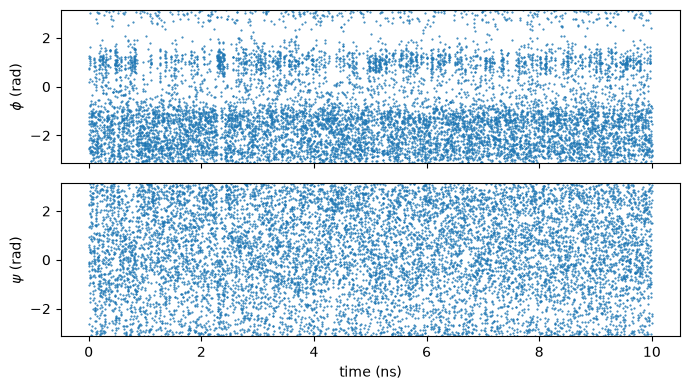

In [7]:
t = np.arange(1, len(trajectory) + 1) / 1000
fig, axes = plt.subplots(2, 1, figsize=(7, 4), sharex=True)
for ax, values, label in zip(axes, trajectory.T, ("$\\phi$", "$\\psi$"), strict=True):
    ax.plot(t, values, ".", markersize=1)
    ax.set_ylabel(f"{label} (rad)")
    ax.set_ylim(-np.pi, np.pi)
axes[-1].set_xlabel("time (ns)")
fig.tight_layout()

`getFreeEnergy()` returns the surface with the last variable varying fastest,
so rows are $\psi$ and columns are $\phi$.

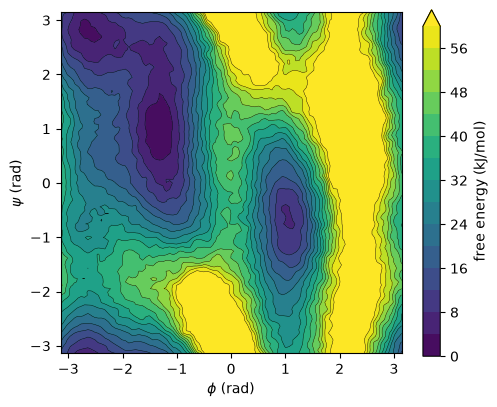

In [8]:
fes -= fes.min()
levels = np.arange(0, 61, 4)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
filled = ax.contourf(grid, grid, fes, levels=levels, cmap="viridis", extend="max")
ax.contour(grid, grid, fes, levels=levels, colors="k", linewidths=0.3)
fig.colorbar(filled, label="free energy (kJ/mol)")
ax.set_xlabel("$\\phi$ (rad)")
ax.set_ylabel("$\\psi$ (rad)")
ax.set_aspect("equal")

Both metrics settle within the first few nanoseconds.

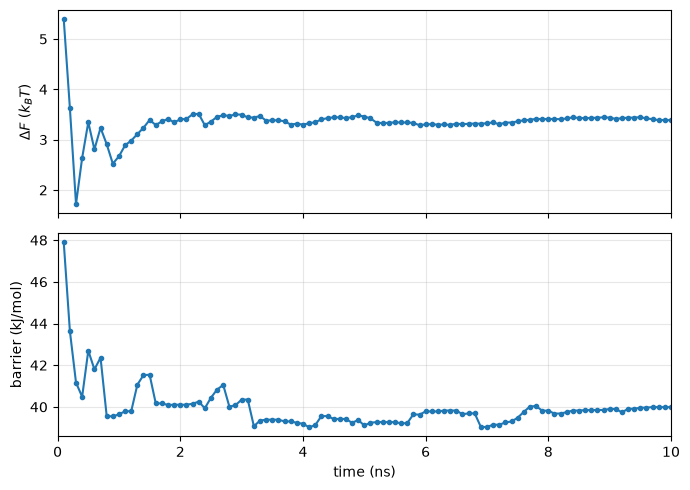

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
axes[0].plot(times, metrics[:, 0], "o-", markersize=3)
axes[0].set_ylabel("$\\Delta F$ ($k_B T$)")
axes[1].plot(times, metrics[:, 1], "o-", markersize=3)
axes[1].set_ylabel("barrier (kJ/mol)")
axes[1].set_xlabel("time (ns)")
axes[1].set_xlim(0, times[-1])
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout()